In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import ast  # <-- NUEVO: Para convertir los colores de texto a tuplas

In [8]:
# ==========================================
# 1. CARGA DE DATOS Y LIMPIEZA. NOMENCLATURAS Y FECHAS
# ==========================================

pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

# Transformamos los colores (que vienen como texto) a tuplas de Python
hospitales['color_rgb'] = hospitales['color'].apply(ast.literal_eval)
# Traducimos las formas al lenguaje de Matplotlib ('dot' -> 'o', 'star' -> '*')
hospitales['forma_nodo'] = hospitales['shape'].map({'dot': 'o', 'star': '*'})

# Renombramos columnas para que sean más intuitivas y fáciles de manejar
pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',

    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',

    'Sexo': 'sexo',
    'Edad': 'edad',

    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',

    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',

    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',

    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',

    'Asistencia Respiratoria Mecánica': 'requiere_arm',

    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',

    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',

    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()


pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})


# Convertimos a datetime para poder operar con tiempos
pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')

# Ordenamos obligatoriamente por paciente y fecha de ingreso para reconstruir la historia
pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. DF AUXILIAR: INCONSISTENCIAS DE ID (Comentado)
# ==========================================
"""
# Detecta IDs que tienen más de una edad o más de un sexo registrado
inconsistencias = df_clean.groupby('paciente_id').agg(
    cant_edades=('Edad', lambda x: x.dropna().nunique()),
    cant_sexos=('Sexo', lambda x: x.dropna().nunique())
)
ids_problematicos = inconsistencias[(inconsistencias['cant_edades'] > 1) | (inconsistencias['cant_sexos'] > 1)].index

# DataFrame con los casos raros para revisar después
df_edades_inconsistentes = df_clean[df_clean['paciente_id'].isin(ids_problematicos)].copy()
"""


# # ==========================================
# # 3. CONSTRUCCIÓN DE TRASLADOS (El core del modelo)
# # ==========================================

pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)
pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'eror_fechas'] = 'Error de carga de datos'
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0


# Definimos qué motivos consideramos como "traslado" real
motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']

# Filtramos: 
# 1. Que haya un destino
# 2. Que el motivo sea de traslado
# 3. (Opcional pero recomendado para tu grafo) Que origen y destino sean distintos

mask_traslados = (
    pacientes['hospital_destino'].notna() &
    pacientes['motivo_egreso'].isin(motivos_validos) &
    (pacientes['hospital_origen'] != pacientes['hospital_destino']) 
)

df_potenciales = pacientes[mask_traslados].copy()
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})


# # ==========================================
# # 4. MANEJO DE TIEMPOS (> 30 días y Alertas)
# # ==========================================

# A. DF Auxiliar: Traslados que tardaron MÁS de 30 días (para consultar/auditar)
df_mas_30_dias = df_potenciales[df_potenciales['dias_traslado'] > 30].copy()

# B. DF Principal de Traslados (<= 30 días)
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()

# Marcamos la alerta (Ejemplo: Si el traslado tardó más de 1 día, es una alerta)
# Podés cambiar el > 1 por el umbral que consideres "demora"
df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 1
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)

# Renombramos para que encaje perfecto con el código del grafo que te pasé antes
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})


# # ==========================================
# # 5. DF DE TRAYECTORIAS (Reconstrucción completa)
# # ==========================================

# Agrupamos por paciente en la base de traslados válidos para ver su "viaje"
def armar_trayectoria(group):
    # Secuencia de hospitales: [Origen1, Destino1(que es Origen2), Destino2, ...]
    # Tomamos todos los orígenes y le sumamos el último destino para tener la ruta completa
    ruta = group['hospital_ingreso'].tolist() + [group['hospital_destino'].iloc[-1]]
    
    # Juntamos los días de alerta en un array/lista (solo guardamos los > 0 para que sea limpio)
    alertas_array = [dias for dias in group['dias_alerta'].tolist() if dias > 0]
    
    return pd.Series({
        'ruta_hospitales': " -> ".join(ruta),
        'cantidad_traslados': len(group),
        'hubo_alerta': len(alertas_array) > 0,
        'dias_alerta_array': alertas_array
    })

# Solo armamos trayectoria de los que tuvieron al menos un traslado exitoso (<= 30 días)
df_trayectoria = df_traslados.groupby('paciente_id').apply(armar_trayectoria).reset_index()

# Mostramos cómo quedaron (opcional)
# print("Traslados listos para el grafo:", len(df_traslados))
# print("Traslados anómalos (>30 días):", len(df_mas_30_dias))
#display(df_trayectoria.head())

In [9]:
# paciente_testigo = 'WN04'
# display(pacientes[pacientes['paciente_id'] == paciente_testigo][['fecha_ingreso', 'hospital_origen', 'motivo_egreso', 'fecha_egreso', 'hospital_destino', 'dias_traslado', 'riesgo_clinico']])

# # Ver las 5 trayectorias con más traslados
# display(df_trayectoria.sort_values('cantidad_traslados', ascending=False).head(5))

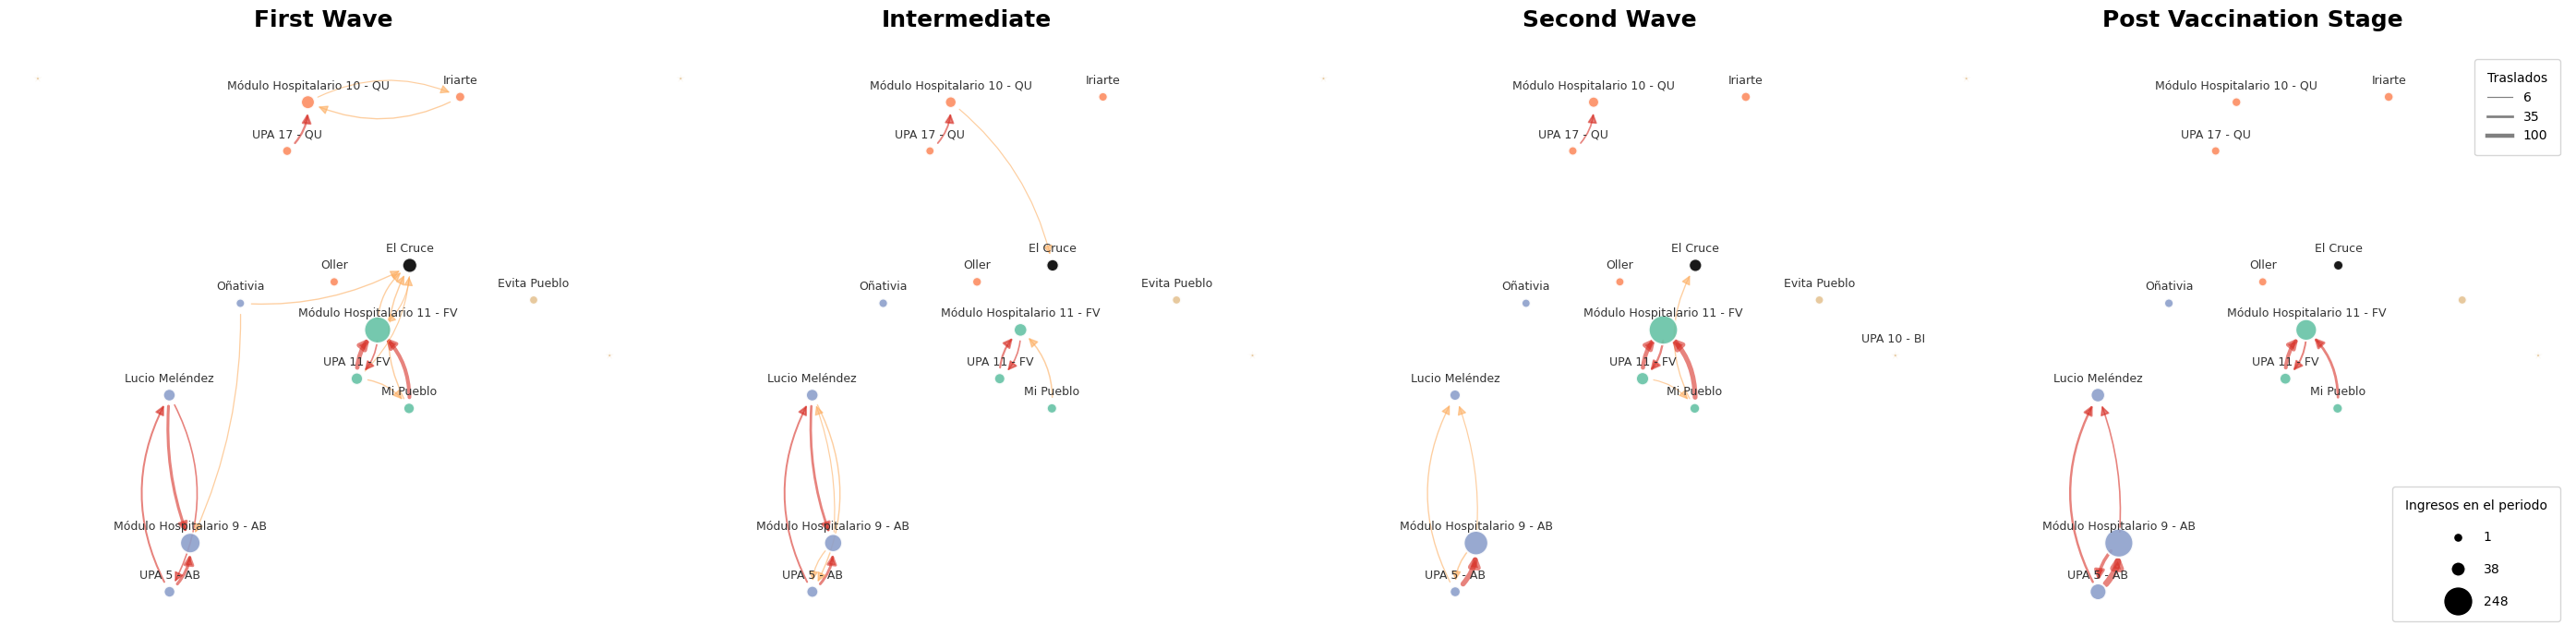

In [10]:

# ==========================================
# 3. PREPARACIÓN DE COORDENADAS
# ==========================================
df_coordenadas = hospitales.rename(columns={
    'Nombre Hospital': 'hospital',
    'Latitud': 'lat',
    'Longitud': 'lon',
    'Localidad': 'localidad'
    # No renombramos 'color' y 'shape' porque ya tienen buenos nombres
})

# Separación de hospitales con mismas coordenadas
groups = df_coordenadas.groupby(['lat', 'lon'])
nuevas_filas = []

for (lat, lon), group in groups:
    if len(group) == 1:
        nuevas_filas.append(group.iloc[0])
    else:
        primeras = True
        for i, (_, row) in enumerate(group.iterrows()):
            row_mod = row.copy()
            if primeras:
                primeras = False
            else:
                row_mod['lon'] = lon + 0.01   
                row_mod['lat'] = lat + (i * 0.015)  
            nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)

# Traductor de formas para NetworkX
mapa_formas = {
    'dot': 'o',   # Círculo
    'star': '*'   # Estrella
}

# ==========================================
# 4. CONFIGURACIÓN VISUAL
# ==========================================
periodos = [
    ('First Wave', '2020-06-01', '2020-10-31'),
    ('Intermediate', '2020-11-01', '2021-02-28'),
    ('Second Wave', '2021-03-01', '2021-07-31'),
    ('Post Vaccination Stage', '2021-08-01', '2022-12-31')
]

# Ya no usamos 'colores_localidad' porque el color viene del CSV

# ==========================================
# 5. DIBUJO DEL GRÁFICO
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(28, 7))
fig.patch.set_facecolor('white')

agrupado_global = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size()
MAX_TRASLADOS_GLOBAL = agrupado_global.max() if not agrupado_global.empty else 1
ingresos_globales = df_traslados['hospital_destino'].value_counts()
MAX_INGRESOS_GLOBAL = ingresos_globales.max() if not ingresos_globales.empty else 1

MIN_GROSOR_ARISTA = 0.1
MAX_GROSOR_ARISTA = 7.0
MIN_TAMANO_NODO = 50
MAX_TAMANO_NODO = 1200

valores_traslados_reales = []
valores_ingresos_reales = []
hospitales_conocidos = set(df_coordenadas['hospital'])

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes[idx]
    ax.set_title(titulo, fontsize=18, fontweight='bold', pad=20)
  
    mask = (df_traslados['fecha_egreso'] >= inicio) & (df_traslados['fecha_egreso'] <= fin)
    df_periodo = df_traslados[mask]
  
    traslados_agrupados = df_periodo.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')
    ingresos_por_hospital = df_periodo['hospital_destino'].value_counts().to_dict()
  
    G = nx.DiGraph()
  
    # Añadir Nodos
    for _, row in df_coordenadas.iterrows():
        h = row['hospital']
        ingresos = ingresos_por_hospital.get(h, 0)
        
        if ingresos > 0:
            valores_ingresos_reales.append(ingresos)

        escala = (ingresos / MAX_INGRESOS_GLOBAL) if MAX_INGRESOS_GLOBAL > 0 else 0
        tamano_nodo = MIN_TAMANO_NODO + (escala * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
        
        # --- NUEVO: Leer color y forma del CSV ---
        try:
            color_rgb = ast.literal_eval(row['color']) # Convierte el string a tupla (R,G,B)
        except:
            color_rgb = 'grey' # Por si alguna fila viene vacía
            
        forma_nodo = mapa_formas.get(row['shape'], 'o') # Convierte 'dot' a 'o', si falla usa 'o'
        
        # Usamos el color del CSV si tuvo ingresos, si no lo pintamos gris clarito
        #color_final = color_rgb if ingresos > 0 else '#e0e0e0'
        # Usamos siempre el color del CSV, sin importar si tuvo ingresos
        color_final = color_rgb
        G.add_node(h, pos=(row['lon'], row['lat']), color=color_final, size=tamano_nodo, shape=forma_nodo)

    # Añadir Aristas
    for _, row in traslados_agrupados.iterrows():
        origen = row['hospital_ingreso']
        destino = row['hospital_destino']
        
        if origen in hospitales_conocidos and destino in hospitales_conocidos:
            G.add_edge(origen, destino, weight=row['peso'])

    posiciones = nx.get_node_attributes(G, 'pos')
    
    # --- NUEVO: DIBUJAR NODOS AGRUPADOS POR FORMA ---
    # NetworkX requiere que todos los nodos de un comando draw tengan la misma forma
    formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
    
    for forma in formas_presentes:
        # Filtramos qué nodos tienen esta forma específica
        nodos_con_esta_forma = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
        
        # Sus colores y tamaños correspondientes
        colores = [G.nodes[n]['color'] for n in nodos_con_esta_forma]
        tamanos = [G.nodes[n]['size'] for n in nodos_con_esta_forma]
        
        nx.draw_networkx_nodes(G, posiciones, nodelist=nodos_con_esta_forma, ax=ax, 
                               node_shape=forma, node_color=colores, node_size=tamanos, 
                               edgecolors='white', linewidths=1.5, alpha=0.9)

    # Dibujar Aristas
    for u, v, data in G.edges(data=True):
        peso = data['weight']

        if peso <= 5: 
            continue
        valores_traslados_reales.append(peso)
        
        escala_peso = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
        grosor = MIN_GROSOR_ARISTA + (escala_peso * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

        if peso > 10: color_flecha = '#d73027'
        elif peso > 5: color_flecha = '#fdae61'
        else: color_flecha = '#1a9850'
    
        suma_caracteres = sum(ord(c) for c in u + v)
        rad_dinamico = (suma_caracteres % 85 - 35) / 100.0
        if abs(rad_dinamico) < 0.12:
            rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

        nx.draw_networkx_edges(G, posiciones, edgelist=[(u, v)], ax=ax,
                                width=grosor, edge_color=color_flecha, alpha=0.6,
                                arrowstyle='-|>', arrowsize=15,
                                connectionstyle=f"arc3,rad={rad_dinamico}")

    # Etiquetas
    labels = {k: k for k in G.nodes() if ingresos_por_hospital.get(k, 0) > 0 or G.out_degree(k) > 0}
    pos_labels = {k: (v[0], v[1] + 0.005) for k, v in posiciones.items() if k in labels}

    nx.draw_networkx_labels(G, pos_labels, labels=labels, ax=ax, font_size=9,
                        font_color='#333333', font_family='sans-serif')

    ax.axis('off')

# ==========================================
# 6. LEYENDAS
# ==========================================
ax_leyenda = axes[-1]

# --- A. TRASLADOS ---
if valores_traslados_reales:
    min_t, med_t, max_t = min(valores_traslados_reales), int(np.mean(valores_traslados_reales)), max(valores_traslados_reales)
else:
    min_t, med_t, max_t = 3, 5, 10

def calc_grosor(peso):
    escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
    return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

line_1 = mlines.Line2D([], [], color='grey', linewidth=calc_grosor(min_t), label=f'{min_t}')
line_2 = mlines.Line2D([], [], color='grey', linewidth=calc_grosor(med_t), label=f'{med_t}')
line_3 = mlines.Line2D([], [], color='grey', linewidth=calc_grosor(100), label=f'{100}')
legend1 = ax_leyenda.legend(handles=[line_1, line_2, line_3], title="Traslados", loc='upper right', frameon=True, borderpad=1)
ax_leyenda.add_artist(legend1)

# --- B. INGRESOS ---
if valores_ingresos_reales:
    min_i, med_i, max_i = min(valores_ingresos_reales), int(np.mean(valores_ingresos_reales)), max(valores_ingresos_reales)
else:
    min_i, med_i, max_i = 10, 50, 100

def calc_markersize(ingreso):
    escala = (ingreso / MAX_INGRESOS_GLOBAL) if MAX_INGRESOS_GLOBAL > 0 else 0
    area = MIN_TAMANO_NODO + (escala * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
    return np.sqrt(area)

node_1 = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='black', markersize=calc_markersize(min_i), label=f'{min_i}')
node_2 = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='black', markersize=calc_markersize(med_i), label=f'{med_i}')
node_3 = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='black', markersize=calc_markersize(max_i), label=f'{max_i}')
legend2 = ax_leyenda.legend(handles=[node_1, node_2, node_3], title="Ingresos en el periodo", loc='lower right', frameon=True, borderpad=1, labelspacing=1.5, handletextpad=1)

plt.tight_layout()
plt.show()

In [11]:
## prueba para ver que tal evita pueblo
inicio = '2020-06-01'
fin = '2020-10-31'


df_periodo = df_traslados[
    (df_traslados['fecha_egreso'] >= inicio) &
    (df_traslados['fecha_egreso'] <= fin)
].copy()


df_evita_a_modulo = df_periodo[
    (df_periodo['hospital_ingreso'] == 'Evita Pueblo') &
    (df_periodo['hospital_destino'] == 'Módulo Hospitalario 10 - QU')
].copy()

cantidad = len(df_evita_a_modulo)
print("Cantidad de traslados:", cantidad)

df_evita_a_modulo

Cantidad de traslados: 1


,hospital_id,hospital_ingreso,paciente_id,fecha_ingreso,estado_ingreso,tipo_ingreso,estado_ultimo,tipo_ultimo,sexo,edad,...,fecha_ultima_actualizacion,paso_criticas,paso_intermedias,paso_generales,hospital_destino,fecha_ingreso_destino,dias_traslado,eror_fechas,alerta_demora,dias_alerta
260,10,Evita Pueblo,AD22,2020-08-26 12:11:23,sospechosos,intermedias,ocupadas_covid,intermedias,femenino,64,...,2020-09-08 09:37:09,no,si,no,Módulo Hospitalario 10 - QU,2020-09-05 12:11:14,0.0,Error de carga de datos,False,0.0
